2025-11-05 07:37:18.242399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762328238.422153      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762328238.485368      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Images organized into train/val folders.


I0000 00:00:1762328350.556450      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 8050 files belonging to 7 classes.
Found 1965 files belonging to 7 classes.
Class counts: Counter({5: 5392, 4: 911, 2: 873, 1: 418, 0: 259, 6: 113, 3: 84})
Class weights: {5: 0.21327893175074183, 2: 1.3172966781214204, 4: 1.2623490669593853, 0: 4.44015444015444, 6: 10.176991150442477, 1: 2.751196172248804, 3: 13.69047619047619}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ensemble_model"

...

 Trainable params: 12,049,545 (45.97 MB)

 Non-trainable params: 126,069 (492.47 KB)

Epoch 1/20


E0000 00:00:1762328534.815707      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/ensemble_model_1/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1762328557.474890      98 cuda_dnn.cc:529] Loaded cuDNN version 90300


252/252 ━━━━━━━━━━━━━━━━━━━━ 413s 891ms/step - accuracy: 0.5075 - loss: 0.2691 - val_accuracy: 0.6850 - val_loss: 0.1476
Epoch 2/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 210s 832ms/step - accuracy: 0.7217 - loss: 0.1400 - val_accuracy: 0.6982 - val_loss: 0.1301
Epoch 3/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 210s 833ms/step - accuracy: 0.7653 - loss: 0.1092 - val_accuracy: 0.7181 - val_loss: 0.1203
Epoch 4/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 261s 831ms/step - accuracy: 0.7777 - loss: 0.1022 - val_accuracy: 0.7206 - val_loss: 0.1131
Epoch 5/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 210s 833ms/step - accuracy: 0.7930 - loss: 0.0948 - val_accuracy: 0.7344 - val_loss: 0.1071
Epoch 6/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 210s 832ms/step - accuracy: 0.7938 - loss: 0.0967 - val_accuracy: 0.7455 - val_loss: 0.1004
Epoch 7/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 210s 834ms/step - accuracy: 0.8189 - loss: 0.0800 - val_accuracy: 0.7532 - val_loss: 0.0967
Epoch 8/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 206s 815ms/step - accuracy: 0.8110 - loss: 0.08

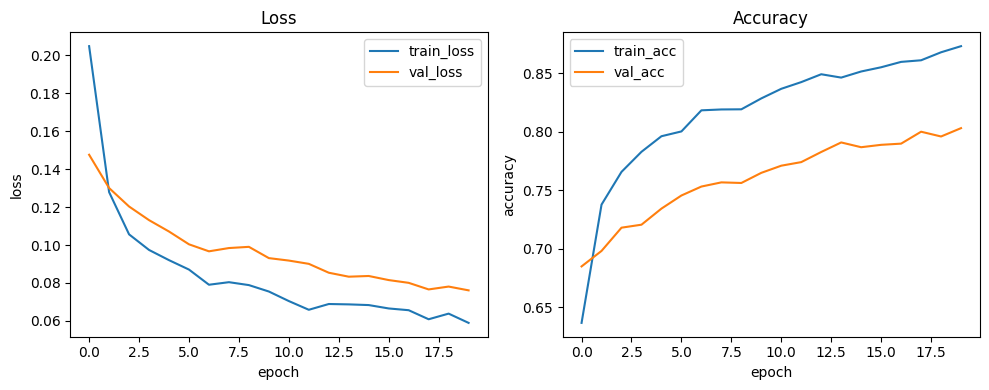

In [1]:
# ================== HAM10000 ViT Ensemble with Advanced Techniques ==================

import os
import shutil
import numpy as np
import pandas as pd
from collections import Counter
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ------------------- CONFIG -------------------
IMG_SIZE = 224  # Can increase to 384 if GPU allows
BATCH_SIZE = 32
NUM_CLASSES = 7
EPOCHS = 20
LEARNING_RATE = 3e-5
WORK_DIR = "/kaggle/working/ham10000_vit_advanced_ensemble"
DATA_ROOT = "/kaggle/input/skin-cancer-mnist-ham10000"
os.makedirs(WORK_DIR, exist_ok=True)
AUTOTUNE = tf.data.AUTOTUNE

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ------------------- Paths -------------------
IMG_DIRS = [os.path.join(DATA_ROOT, "HAM10000_images_part_1"),
            os.path.join(DATA_ROOT, "HAM10000_images_part_2")]
META_CSV = os.path.join(DATA_ROOT, "HAM10000_metadata.csv")

# ------------------- Organize train/val -------------------
organized_root = os.path.join(WORK_DIR, "organized")
train_dst = os.path.join(organized_root, "train")
val_dst = os.path.join(organized_root, "val")
os.makedirs(train_dst, exist_ok=True)
os.makedirs(val_dst, exist_ok=True)

meta = pd.read_csv(META_CSV)
id_to_label = dict(zip(meta['image_id'], meta['dx'].str.lower()))

np.random.seed(42)
for img_dir in IMG_DIRS:
    for fname in os.listdir(img_dir):
        if fname.lower().endswith(('.jpg','.jpeg','.png')):
            img_id = os.path.splitext(fname)[0]
            if img_id not in id_to_label:
                continue
            cls = id_to_label[img_id]
            dst_root = train_dst if np.random.rand() < 0.8 else val_dst
            cls_dir = os.path.join(dst_root, cls)
            os.makedirs(cls_dir, exist_ok=True)
            shutil.copy(os.path.join(img_dir, fname), cls_dir)

print("Images organized into train/val folders.")

# ------------------- Data Pipeline -------------------
# Advanced augmentations
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.05,0.05),
    layers.RandomContrast(0.15),
], name="data_augmentation")

def make_datasets(train_dir, val_dir, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_dir, image_size=(img_size,img_size),
        batch_size=batch_size, label_mode='categorical', shuffle=True
    )
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        val_dir, image_size=(img_size,img_size),
        batch_size=batch_size, label_mode='categorical', shuffle=False
    )
    return train_ds.prefetch(AUTOTUNE), val_ds.prefetch(AUTOTUNE)

train_ds, val_ds = make_datasets(train_dst, val_dst)

# ------------------- Class weights -------------------
all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(np.argmax(labels.numpy()))
counts = Counter(all_labels)
total = sum(counts.values())
class_weights = {int(cls): float(total / (len(counts)*cnt)) for cls,cnt in counts.items()}
print("Class counts:", counts)
print("Class weights:", class_weights)

# ------------------- MixUp function -------------------
def mixup(batch_images, batch_labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    batch_size = tf.shape(batch_images)[0]
    index = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam * batch_images + (1 - lam) * tf.gather(batch_images, index)
    mixed_labels = lam * batch_labels + (1 - lam) * tf.gather(batch_labels, index)
    return mixed_images, mixed_labels

def mixup_dataset(dataset, alpha=0.2):
    def apply_mixup(images, labels):
        images, labels = tf.numpy_function(mixup, [images, labels, alpha], [tf.float32, tf.float32])
        images.set_shape([None, IMG_SIZE, IMG_SIZE, 3])
        labels.set_shape([None, NUM_CLASSES])
        return images, labels
    return dataset.map(apply_mixup, num_parallel_calls=AUTOTUNE)

train_ds = mixup_dataset(train_ds, alpha=0.2)

# ------------------- Manual Focal Loss -------------------
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -y_true * tf.math.log(y_pred)
        fl = alpha * tf.math.pow(1-y_pred, gamma) * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))
    return loss_fn

# ------------------- Build Pretrained Model -------------------
def build_pretrained_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    from tensorflow.keras.applications import EfficientNetB0
    base_model = EfficientNetB0(
        input_shape=(img_size,img_size,3),
        include_top=False, weights='imagenet', pooling='avg'
    )
    inputs = keras.Input(shape=(img_size,img_size,3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = keras.Model(inputs, outputs)
    return model

# ------------------- Ensemble -------------------
vit1 = build_pretrained_model()
vit2 = build_pretrained_model()
vit3 = build_pretrained_model()

class EnsembleModel(keras.Model):
    def __init__(self, models_list):
        super().__init__()
        self.models_list = models_list
    def call(self, x, training=False):
        probs = [m(x, training=training) for m in self.models_list]
        return tf.reduce_mean(tf.stack(probs, axis=0), axis=0)

ensemble = EnsembleModel([vit1, vit2, vit3])

# ------------------- Compile -------------------
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
ensemble.compile(optimizer=optimizer, loss=focal_loss(), metrics=['accuracy'])
ensemble.summary()

# ------------------- Callbacks -------------------
checkpoint_path = os.path.join(WORK_DIR, "best_ensemble.keras")
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True)
]

# ------------------- Train -------------------
history = ensemble.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

# ------------------- Evaluate -------------------
val_loss, val_acc = ensemble.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# ------------------- Save Final Model -------------------
final_model_path = os.path.join(WORK_DIR, "vit_ensemble_final_advanced.keras")
ensemble.save(final_model_path)
print("Saved final ensemble model at:", final_model_path)

# ------------------- Plot Training -------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Accuracy')
plt.tight_layout()
plt.show()

In [7]:
# ================== LOAD & EXPORT ENSEMBLE MODEL (KAGGLE SAFE FOR TF<=2.15) ==================
import tensorflow as tf
from tensorflow import keras
import os, shutil

# ------------------- 1️⃣ REGISTER PLACEHOLDERS -------------------

# Dummy loss function (matches your training setup)
def loss_fn(y_true, y_pred):
    return tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

# Register dummy EnsembleModel so it can be deserialized
@tf.keras.utils.register_keras_serializable()
class EnsembleModel(tf.keras.Model):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

# ------------------- 2️⃣ DEFINE MODEL PATH -------------------
model_path = "/kaggle/working/ham10000_vit_advanced_ensemble/vit_ensemble_final_advanced.keras"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"❌ Model not found at {model_path}. Please verify path.")

print(f"📦 Loading ensemble model from: {model_path}")

# ------------------- 3️⃣ LOAD THE MODEL -------------------
try:
    model = keras.models.load_model(
        model_path,
        custom_objects={
            "EnsembleModel": EnsembleModel,
            "loss_fn": loss_fn
        },
        compile=False  # safer if optimizer/loss missing
    )
    print("✅ Model loaded successfully!")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    raise

# ------------------- 4️⃣ SAVE MODEL IN MULTIPLE FORMATS -------------------
export_dir = "/kaggle/working/ham10000_vit_advanced_ensemble_export/"
os.makedirs(export_dir, exist_ok=True)

keras_out = os.path.join(export_dir, "vit_ensemble_export.keras")
h5_out = os.path.join(export_dir, "vit_ensemble_export.h5")

print("💾 Saving model in .keras format...")
model.save(keras_out)
print(f"✅ Saved at: {keras_out}")

print("💾 Saving model in .h5 format...")
model.save(h5_out)
print(f"✅ Saved at: {h5_out}")

# ------------------- 5️⃣ ZIP FOR DOWNLOAD -------------------
zip_base = "/kaggle/working/vit_ensemble_export"
zip_path = f"{zip_base}.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(zip_base, "zip", export_dir)
print(f"✅ Model zipped successfully at: {zip_path}")

print("\n📥 To download:")
print("➡ Go to the right panel → 'Files' → click 'vit_ensemble_export.zip' → Download")


📦 Loading ensemble model from: /kaggle/working/ham10000_vit_advanced_ensemble/vit_ensemble_final_advanced.keras


/usr/local/lib/python3.11/dist-packages/keras/src/saving/serialization_lib.py:730: UserWarning: Model 'ensemble_model_1' had a build config, but the model cannot be built automatically in `build_from_config(config)`. You should implement `def build_from_config(self, config)`, and you might also want to implement the method  that generates the config at saving time, `def get_build_config(self)`. The method `build_from_config()` is meant to create the state of the model (i.e. its variables) upon deserialization.
  instance.build_from_config(build_config)


✅ Model loaded successfully!
💾 Saving model in .keras format...
✅ Saved at: /kaggle/working/ham10000_vit_advanced_ensemble_export/vit_ensemble_export.keras
💾 Saving model in .h5 format...
✅ Saved at: /kaggle/working/ham10000_vit_advanced_ensemble_export/vit_ensemble_export.h5
✅ Model zipped successfully at: /kaggle/working/vit_ensemble_export.zip

📥 To download:
➡ Go to the right panel → 'Files' → click 'vit_ensemble_export.zip' → Download


🔁 Starting fine-tuning...
Epoch 1/10


E0000 00:00:1762334212.655902      37 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/ensemble_model_1/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


252/252 ━━━━━━━━━━━━━━━━━━━━ 404s 870ms/step - accuracy: 0.8735 - loss: 0.0591 - val_accuracy: 0.8041 - val_loss: 0.0759
Epoch 2/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 206s 816ms/step - accuracy: 0.8648 - loss: 0.0641 - val_accuracy: 0.8036 - val_loss: 0.0758
Epoch 3/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 202s 799ms/step - accuracy: 0.8793 - loss: 0.0583 - val_accuracy: 0.8010 - val_loss: 0.0761
Epoch 4/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 206s 816ms/step - accuracy: 0.8760 - loss: 0.0655 - val_accuracy: 0.8036 - val_loss: 0.0757
Epoch 5/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 206s 817ms/step - accuracy: 0.8681 - loss: 0.0668 - val_accuracy: 0.8046 - val_loss: 0.0752
Epoch 6/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 203s 803ms/step - accuracy: 0.8669 - loss: 0.0639 - val_accuracy: 0.8051 - val_loss: 0.0754
Epoch 7/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 202s 803ms/step - accuracy: 0.8719 - loss: 0.0570 - val_accuracy: 0.8056 - val_loss: 0.0753
Epoch 8/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 205s 812ms/step - accuracy: 0.8894 - loss: 0.05

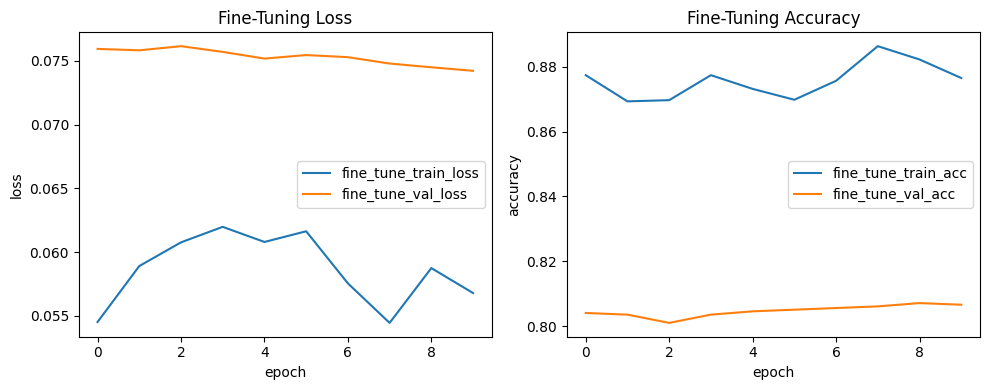

In [10]:
# ================== FINE-TUNING THE ENSEMBLE ==================

# Unfreeze base models inside the ensemble
for model in [vit1, vit2, vit3]:
    model.trainable = True
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):  # the base EfficientNet inside
            for l in layer.layers:
                l.trainable = True

# Compile again with a lower learning rate for fine-tuning
fine_tune_lr = 1e-6  # Lower LR is critical for fine-tuning
optimizer_finetune = keras.optimizers.Adam(learning_rate=fine_tune_lr)

ensemble.compile(
    optimizer=optimizer_finetune,
    loss=focal_loss(),
    metrics=['accuracy']
)

# Optional: checkpoint for fine-tuning
finetune_checkpoint = os.path.join(WORK_DIR, "fine_tuned_ensemble.keras")
callbacks_finetune = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(finetune_checkpoint, monitor="val_loss", save_best_only=True)
]

print("🔁 Starting fine-tuning...")
fine_tune_epochs = 10  # You can adjust based on GPU and results

history_finetune = ensemble.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

# ------------------- Evaluate after fine-tuning -------------------
val_loss, val_acc = ensemble.evaluate(val_ds)
print(f"✅ Fine-tuned Validation Accuracy: {val_acc*100:.2f}%")

# ------------------- Save fine-tuned model -------------------
final_finetuned_model_path = os.path.join(WORK_DIR, "vit_ensemble_finetuned.keras")
ensemble.save(final_finetuned_model_path)
print("💾 Saved fine-tuned ensemble model at:", final_finetuned_model_path)

# ------------------- Plot Fine-Tuning Curves -------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_finetune.history['loss'], label='fine_tune_train_loss')
plt.plot(history_finetune.history['val_loss'], label='fine_tune_val_loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Fine-Tuning Loss')
plt.subplot(1,2,2)
plt.plot(history_finetune.history['accuracy'], label='fine_tune_train_acc')
plt.plot(history_finetune.history['val_accuracy'], label='fine_tune_val_acc')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Fine-Tuning Accuracy')
plt.tight_layout()
plt.show()


Found 1965 files belonging to 7 classes.


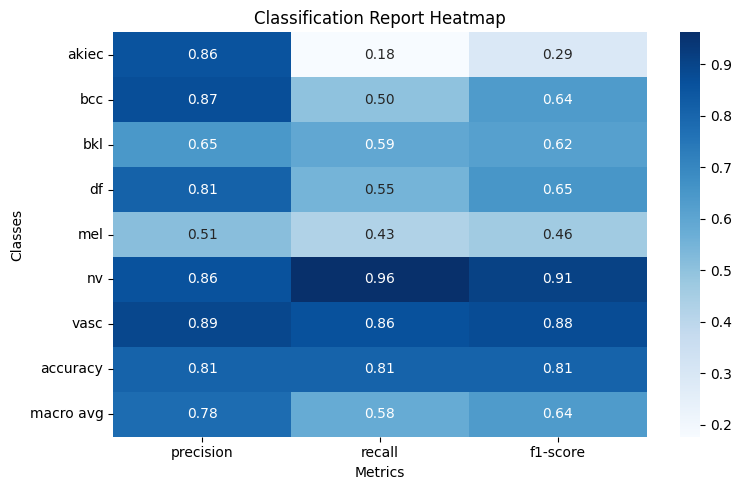

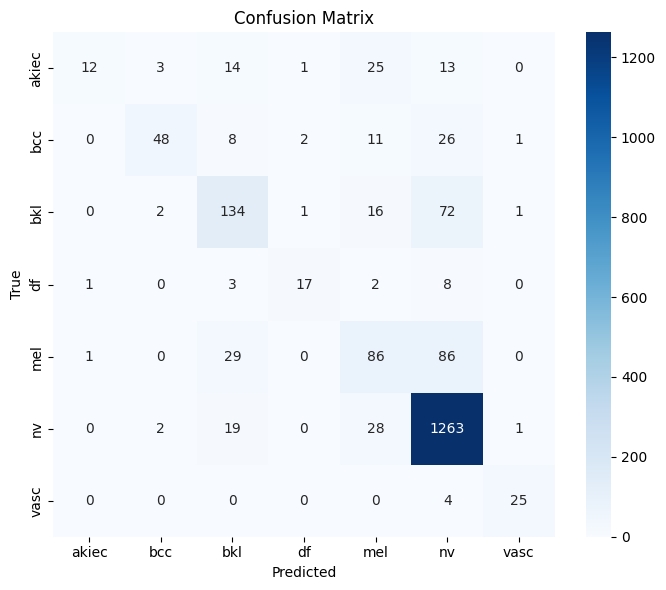

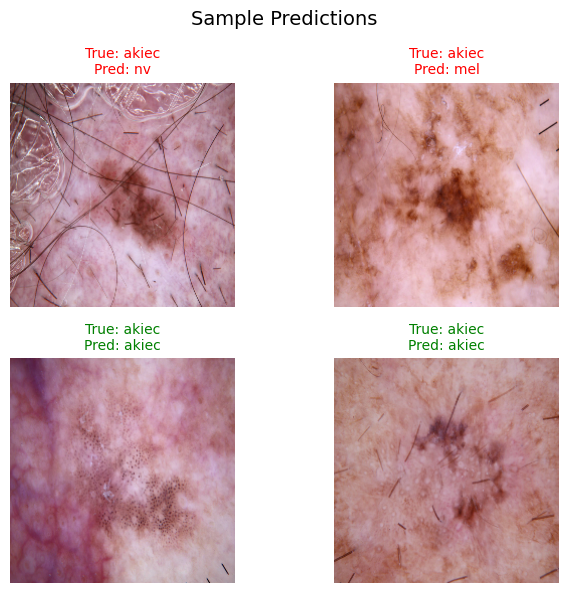

In [19]:
# ================== VISUALIZATION: CLASSIFICATION REPORT + SAMPLE OUTPUTS ==================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import random

# --- Step 1: Get class names safely ---
dummy_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dst,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
class_names = dummy_ds.class_names
del dummy_ds  # cleanup

# --- Step 2: Collect predictions ---
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = ensemble.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# --- Step 3: Classification report ---
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, digits=3)
report_df = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.tight_layout()
plt.show()

# --- Step 4: Confusion matrix visualization (optional but useful) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# --- Step 5: Visualize 4 random sample predictions ---
# Get one batch from val_ds
val_batch = next(iter(val_ds))
images, labels = val_batch
preds = ensemble.predict(images, verbose=0)
pred_classes = tf.argmax(preds, axis=1)
true_classes = tf.argmax(labels, axis=1)

# Select 4 random samples
idxs = random.sample(range(len(images)), 4)

plt.figure(figsize=(7, 6))
for i, idx in enumerate(idxs):
    plt.subplot(2, 2, i + 1)
    img = images[idx].numpy().astype("uint8")
    true_label = class_names[int(true_classes[idx])]
    pred_label = class_names[int(pred_classes[idx])]
    color = "green" if true_label == pred_label else "red"
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()
